# Mondrian conformal HDF5 demo

This notebook runs Mondrian conformal analysis using saved CNN predictions, labels, and embeddings.

It supports two modes:

- real calibration/test mode, using `pred_cal`, `y_cal`, `emb_cal`, `pred_test`, `y_test`, and `emb_test`
- debug mode, where validation predictions are split into pseudo-calibration and pseudo-test subsets

Debug mode is useful for testing the pipeline, but must not be reported as final conformal performance.

In [1]:
from pathlib import Path
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import iqr

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name != "cbc_pe" and (PROJECT_ROOT / "cbc_pe").exists():
    PROJECT_ROOT = PROJECT_ROOT / "cbc_pe"

os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_ROOT = Path("/scratch/vserrano/cbc_pe_data")
DATA_RESULTS = DATA_ROOT / "results"

dataset_id = "bbh_processed_4s_seobnrv4opt_snr10-25_n100_000"
RESULTS_DIR = DATA_RESULTS / dataset_id

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("RESULTS_DIR:", RESULTS_DIR)
print("RESULTS_DIR exists:", RESULTS_DIR.exists())

PROJECT_ROOT: /afs/ciemat.es/user/v/vserrano/Desktop/gw/Gravitational-Waves-Lab/cbc_pe/notebooks
DATA_ROOT: /scratch/vserrano/cbc_pe_data
RESULTS_DIR: /scratch/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n100_000
RESULTS_DIR exists: True


## Select prediction file

For the current 100k architecture-search setup, calibration and test sets are not available. Use debug mode only for pipeline development.

For final reporting, use a prediction file produced from a 70/10/10/10 or similar train/validation/calibration/test split.

In [2]:
MODEL_ID = "M00_baseline_emb64_seed123"

prediction_files = {
    "M00_baseline_emb64_seed123": RESULTS_DIR / (
        "bbh_processed_4s_seobnrv4opt_snr10-25_n100_000"
        "_SimpleCNN_Baseline_M00_simple_emb64_mse_MSELoss_seed123"
        "_train_val_predictions_embeddings.npz"
    ),
    "M00_baseline_emb64_seed124": RESULTS_DIR / (
        "bbh_processed_4s_seobnrv4opt_snr10-25_n100_000"
        "_SimpleCNN_Baseline_M00_simple_emb64_mse_MSELoss_seed124"
        "_train_val_predictions_embeddings.npz"
    ),
    "M04_pooldeep_emb128_pool4": RESULTS_DIR / (
        "bbh_processed_4s_seobnrv4opt_snr10-25_n100_000"
        "_SimpleCNN_PoolDeep_M04_emb128_pool4_deephead_MSELoss_seed123"
        "_train_val_predictions_embeddings.npz"
    ),
}

prediction_file = prediction_files[MODEL_ID]

assert prediction_file.exists(), prediction_file

print("MODEL_ID:", MODEL_ID)
print("prediction_file:", prediction_file)

data = np.load(prediction_file, allow_pickle=True)
print(data.files)

MODEL_ID: M00_baseline_emb64_seed123
prediction_file: /scratch/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n100_000/bbh_processed_4s_seobnrv4opt_snr10-25_n100_000_SimpleCNN_Baseline_M00_simple_emb64_mse_MSELoss_seed123_train_val_predictions_embeddings.npz
['pred_train', 'emb_train', 'y_train', 'pred_val', 'emb_val', 'y_val', 'y_mean', 'y_std', 'train_idx', 'val_idx', 'label_names', 'checkpoint_file', 'dataset_path', 'split_path', 'label_stats_path']


## Build calibration and test arrays

In [3]:
def load_conformal_arrays(
    data,
    debug_split_val=False,
    debug_cal_fraction=0.5,
    debug_seed=123,
):
    """
    Load arrays needed for Mondrian/conformal.

    Preferred real mode:
        pred_cal, y_cal, emb_cal
        pred_test, y_test, emb_test

    Debug mode:
        If real cal/test are not available, split val into pseudo_cal/pseudo_test.
        This is only for debugging the notebook, not for final reporting.
    """

    files = set(data.files)

    has_real_cal_test = {
        "pred_cal",
        "y_cal",
        "emb_cal",
        "pred_test",
        "y_test",
        "emb_test",
    }.issubset(files)

    if has_real_cal_test:
        print("Using real cal/test arrays.")

        pred_cal = data["pred_cal"]
        y_cal = data["y_cal"]
        emb_cal = data["emb_cal"]

        pred_test = data["pred_test"]
        y_test = data["y_test"]
        emb_test = data["emb_test"]

        idx_cal = data["idx_cal"] if "idx_cal" in files else None
        idx_test = data["idx_test"] if "idx_test" in files else None

        mode = "real_cal_test"

    else:
        if not debug_split_val:
            raise KeyError(
                "No real cal/test arrays found in prediction file. "
                "Expected pred_cal/y_cal/emb_cal and pred_test/y_test/emb_test. "
                "For notebook debugging only, set debug_split_val=True."
            )

        required_val = {"pred_val", "y_val", "emb_val"}

        if not required_val.issubset(files):
            raise KeyError(
                "Cannot create debug split because pred_val/y_val/emb_val are missing."
            )

        print("WARNING: using validation split as pseudo cal/test.")
        print("This is only for debugging. Do not report these results as final.")

        pred_val = data["pred_val"]
        y_val = data["y_val"]
        emb_val = data["emb_val"]

        n_val = pred_val.shape[0]
        rng = np.random.default_rng(debug_seed)
        perm = rng.permutation(n_val)

        n_cal = int(debug_cal_fraction * n_val)

        cal_local = perm[:n_cal]
        test_local = perm[n_cal:]

        pred_cal = pred_val[cal_local]
        y_cal = y_val[cal_local]
        emb_cal = emb_val[cal_local]

        pred_test = pred_val[test_local]
        y_test = y_val[test_local]
        emb_test = emb_val[test_local]

        if "idx_val" in files:
            idx_val = data["idx_val"]
            idx_cal = idx_val[cal_local]
            idx_test = idx_val[test_local]
        else:
            idx_cal = cal_local
            idx_test = test_local

        mode = "debug_val_split"

    y_mean = data["y_mean"]
    y_std = data["y_std"]

    if "label_names" in files:
        label_names = data["label_names"].tolist()
    else:
        label_names = ["chirp_mass", "total_mass", "chi_eff"]

    return {
        "mode": mode,
        "pred_cal": pred_cal,
        "y_cal": y_cal,
        "emb_cal": emb_cal,
        "pred_test": pred_test,
        "y_test": y_test,
        "emb_test": emb_test,
        "idx_cal": idx_cal,
        "idx_test": idx_test,
        "y_mean": y_mean,
        "y_std": y_std,
        "label_names": label_names,
    }

In [4]:
DEBUG_SPLIT_VAL = True  # Debug only. Do not report as final conformal performance.

arrays = load_conformal_arrays(
    data,
    debug_split_val=DEBUG_SPLIT_VAL,
    debug_cal_fraction=0.5,
    debug_seed=123,
)

mode = arrays["mode"]

pred_cal = arrays["pred_cal"]
y_cal = arrays["y_cal"]
emb_cal = arrays["emb_cal"]

pred_test = arrays["pred_test"]
y_test = arrays["y_test"]
emb_test = arrays["emb_test"]

y_mean = arrays["y_mean"]
y_std = arrays["y_std"]
label_names = arrays["label_names"]

print("mode:", mode)
print("pred_cal:", pred_cal.shape)
print("pred_test:", pred_test.shape)
print("labels:", label_names)

if mode != "real_cal_test":
    print("WARNING: running in debug pseudo-cal/test mode. Do not report as final conformal performance.")

This is only for debugging. Do not report these results as final.
mode: debug_val_split
pred_cal: (10000, 3)
pred_test: (10000, 3)
labels: ['chirp_mass', 'total_mass', 'chi_eff']


In [5]:
mode = arrays["mode"]

pred_cal = arrays["pred_cal"]
y_cal = arrays["y_cal"]
emb_cal = arrays["emb_cal"]

pred_test = arrays["pred_test"]
y_test = arrays["y_test"]
emb_test = arrays["emb_test"]

idx_cal = arrays["idx_cal"]
idx_test = arrays["idx_test"]

y_mean = arrays["y_mean"]
y_std = arrays["y_std"]
label_names = arrays["label_names"]

print("mode:", mode)
print("pred_cal:", pred_cal.shape)
print("y_cal:", y_cal.shape)
print("emb_cal:", emb_cal.shape)
print("pred_test:", pred_test.shape)
print("y_test:", y_test.shape)
print("emb_test:", emb_test.shape)
print("y_mean:", y_mean)
print("y_std:", y_std)
print("label_names:", label_names)

mode: debug_val_split
pred_cal: (10000, 3)
y_cal: (10000, 3)
emb_cal: (10000, 64)
pred_test: (10000, 3)
y_test: (10000, 3)
emb_test: (10000, 64)
y_mean: [ 3.7574448e+01  9.5240074e+01 -2.6193226e-04]
y_std: [16.527256  34.736935   0.4393742]
label_names: ['chirp_mass', 'total_mass', 'chi_eff']


In [6]:
#Sanity Checks
assert pred_cal.ndim == 2
assert pred_test.ndim == 2
assert y_cal.ndim == 2
assert y_test.ndim == 2

assert pred_cal.shape == y_cal.shape
assert pred_test.shape == y_test.shape

assert pred_cal.shape[1] == len(label_names)
assert pred_test.shape[1] == len(label_names)

assert emb_cal.ndim == 2
assert emb_test.ndim == 2

assert emb_cal.shape[0] == pred_cal.shape[0]
assert emb_test.shape[0] == pred_test.shape[0]

assert y_mean.shape[0] == len(label_names)
assert y_std.shape[0] == len(label_names)
assert np.all(y_std > 0)

for name, arr in {
    "pred_cal": pred_cal,
    "y_cal": y_cal,
    "pred_test": pred_test,
    "y_test": y_test,
    "emb_cal": emb_cal,
    "emb_test": emb_test,
    "y_mean": y_mean,
    "y_std": y_std,
}.items():
    assert np.all(np.isfinite(arr)), f"{name} contains NaN or inf"

if mode != "real_cal_test":
    print("WARNING: notebook is running in debug mode:", mode)
    print("Do not use these results as final conformal/Mondrian results.")

print("All sanity checks passed.")

Do not use these results as final conformal/Mondrian results.
All sanity checks passed.


In [7]:
def inverse_standardize(y_std_values, y_mean, y_std):
    return y_std_values * y_std + y_mean


y_cal_phys = inverse_standardize(y_cal, y_mean, y_std)
y_test_phys = inverse_standardize(y_test, y_mean, y_std)

pred_cal_phys = inverse_standardize(pred_cal, y_mean, y_std)
pred_test_phys = inverse_standardize(pred_test, y_mean, y_std)

label_ranges_phys = {
    label: np.max(y_test_phys[:, j]) - np.min(y_test_phys[:, j])
    for j, label in enumerate(label_names)
}

label_ranges_phys

{'chirp_mass': np.float32(72.82364),
 'total_mass': np.float32(167.25894),
 'chi_eff': np.float32(1.9830375)}

## Start Mondrian

In [8]:
confidence_level = 0.90

if mode == "real_cal_test":
    n_bins_grid = [4, 6, 8, 12, 16, 24, 32, 48]
else:
    n_bins_grid = [4, 6, 8, 12, 16, 24]

taxonomy_modes = ["prediction", "difficulty"]
interval_modes = ["symmetric", "asymmetric"]

n_neighbors = 5
min_samples_per_bin = 20 if mode == "real_cal_test" else 10

rows = []
all_results = {}

In [9]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("/afs/ciemat.es/user/v/vserrano/Desktop/gw/Gravitational-Waves-Lab/cbc_pe")  # ajusta si tu repo está en otra ruta

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT)

/afs/ciemat.es/user/v/vserrano/Desktop/gw/Gravitational-Waves-Lab/cbc_pe


In [10]:
from src.conformal.pipeline import run_mondrian_regression

for taxonomy_mode in taxonomy_modes:
    for interval_mode in interval_modes:
        for n_bins in n_bins_grid:

            kwargs = dict(
                pred_cal=pred_cal,
                pred_test=pred_test,
                y_cal=y_cal,
                y_test=y_test,
                n_bins=n_bins,
                confidence_level=confidence_level,
                apply_jitter=True,
                interval_mode=interval_mode,
                taxonomy_mode=taxonomy_mode,
                min_samples_per_bin=min_samples_per_bin,
                tolerance_sigmas=(1, 2, 3),
            )

            if taxonomy_mode == "difficulty":
                kwargs.update(
                    cal_embedding=emb_cal,
                    target_embedding=emb_test,
                    n_neighbors=n_neighbors,
                )

            result = run_mondrian_regression(**kwargs)
            all_results[(taxonomy_mode, interval_mode, n_bins)] = result

            metrics = result.metrics

            widths_std = result.upper - result.lower
            widths_phys = widths_std * y_std

            for j, label in enumerate(label_names):
                n_bad_bins_p005 = int(
                    np.nansum(metrics["bin_undercoverage_pvalue"][:, j] < 0.05)
                )

                row = {
                    "mode": mode,
                    "taxonomy_mode": taxonomy_mode,
                    "interval_mode": interval_mode,
                    "n_bins": n_bins,
                    "label": label,
                    "label_index": j,

                    "n_samples": int(metrics["n_samples_per_label"][j]),
                    "covered_count": int(metrics["covered_count_global"][j]),

                    "global_coverage": metrics["global_coverage"][j],
                    "miscoverage": metrics["miscoverage"][j],
                    "global_coverage_gap": metrics["global_coverage_gap"][j],
                    "global_undercoverage_pvalue": metrics["global_undercoverage_pvalue"][j],

                    "global_mean_width_std": metrics["global_mean_width"][j],
                    "global_median_width_std": metrics["global_median_width"][j],

                    "global_mean_width_phys": np.mean(widths_phys[:, j]),
                    "global_median_width_phys": np.median(widths_phys[:, j]),
                    "global_iqr_width_phys": iqr(widths_phys[:, j]),

                    "normalized_median_width_range": (
                        np.median(widths_phys[:, j]) / label_ranges_phys[label]
                    ),

                    "min_coverage_per_bin": metrics["min_coverage_per_label"][j],
                    "max_undercoverage_gap": metrics["max_undercoverage_gap"][j],

                    "min_count_per_bin": int(np.nanmin(metrics["counts_per_bin"][:, j])),
                    "max_count_per_bin": int(np.nanmax(metrics["counts_per_bin"][:, j])),

                    "n_bad_bins_p005": n_bad_bins_p005,
                    "bad_bin_fraction": n_bad_bins_p005 / n_bins,

                    "global_lower_miss_rate": metrics["global_lower_miss_rate"][j],
                    "global_upper_miss_rate": metrics["global_upper_miss_rate"][j],
                    "global_tail_miss_imbalance": metrics["global_tail_miss_imbalance"][j],
                }

                global_tol = metrics["global_tolerance_normal"]

                for k in [1, 2, 3]:
                    low = global_tol[f"{k}sigma_low"][j]
                    high = global_tol[f"{k}sigma_high"][j]
                    width = global_tol[f"{k}sigma_width"][j]

                    row[f"global_tol_{k}sigma_low"] = low
                    row[f"global_tol_{k}sigma_high"] = high
                    row[f"global_tol_{k}sigma_width"] = width
                    row[f"global_within_{k}sigma"] = bool(low <= metrics["global_coverage"][j] <= high)

                rows.append(row)

summary_df = pd.DataFrame(rows)
summary_df

,mode,taxonomy_mode,interval_mode,n_bins,label,label_index,n_samples,covered_count,global_coverage,miscoverage,global_coverage_gap,global_undercoverage_pvalue,global_mean_width_std,global_median_width_std,global_mean_width_phys,global_median_width_phys,global_iqr_width_phys,normalized_median_width_range,min_coverage_per_bin,max_undercoverage_gap,min_count_per_bin,max_count_per_bin,n_bad_bins_p005,bad_bin_fraction,global_lower_miss_rate,global_upper_miss_rate,global_tail_miss_imbalance,global_tol_1sigma_low,global_tol_1sigma_high,global_tol_1sigma_width,global_within_1sigma,global_tol_2sigma_low,global_tol_2sigma_high,global_tol_2sigma_width,global_within_2sigma,global_tol_3sigma_low,global_tol_3sigma_high,global_tol_3sigma_width,global_within_3sigma
0,debug_val_split,prediction,symmetric,4,chirp_mass,0,10000,8910,0.8910,0.1090,0.0090,0.001591,1.143067,1.349212,18.891762,22.298778,10.978929,0.306202,0.887239,0.012761,2361,2587,2,0.500000,0.0625,0.0465,0.0160,0.897,0.903,0.003,False,0.894,0.906,0.006,False,0.891,0.909,0.009,True
1,debug_val_split,prediction,symmetric,4,total_mass,1,10000,8954,0.8954,0.1046,0.0046,0.065389,1.073251,1.115891,37.281443,38.762632,6.943318,0.231752,0.890004,0.009996,2391,2573,0,0.000000,0.0539,0.0507,0.0032,0.897,0.903,0.003,False,0.894,0.906,0.006,True,0.891,0.909,0.009,True
2,debug_val_split,prediction,symmetric,4,chi_eff,2,10000,9049,0.9049,0.0951,0.0049,0.951329,1.718774,1.543431,0.755185,0.678144,0.200765,0.341972,0.889755,0.010245,2432,2567,1,0.250000,0.0531,0.0420,0.0111,0.897,0.903,0.003,False,0.894,0.906,0.006,True,0.891,0.909,0.009,True
3,debug_val_split,prediction,symmetric,6,chirp_mass,0,10000,8942,0.8942,0.1058,0.0058,0.028382,1.147843,1.293987,18.970695,21.386050,8.300854,0.293669,0.883450,0.016550,1591,1755,1,0.166667,0.0621,0.0437,0.0184,0.897,0.903,0.003,False,0.894,0.906,0.006,True,0.891,0.909,0.009,True
4,debug_val_split,prediction,symmetric,6,total_mass,1,10000,8949,0.8949,0.1051,0.0051,0.046927,1.077199,1.099665,37.418603,38.198992,5.933905,0.228382,0.875073,0.024927,1523,1728,1,0.166667,0.0540,0.0511,0.0029,0.897,0.903,0.003,False,0.894,0.906,0.006,True,0.891,0.909,0.009,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,debug_val_split,difficulty,asymmetric,16,total_mass,1,10000,8953,0.8953,0.1047,0.0047,0.061302,1.052814,0.988331,36.571532,34.331580,11.920360,0.205260,0.861017,0.038983,585,666,2,0.125000,0.0558,0.0489,0.0069,0.897,0.903,0.003,False,0.894,0.906,0.006,True,0.891,0.909,0.009,True
68,debug_val_split,difficulty,asymmetric,16,chi_eff,2,10000,9039,0.9039,0.0961,0.0039,0.906586,1.688737,1.574111,0.741987,0.691624,0.233841,0.348770,0.875405,0.024595,568,682,2,0.125000,0.0493,0.0468,0.0025,0.897,0.903,0.003,False,0.894,0.906,0.006,True,0.891,0.909,0.009,True
69,debug_val_split,difficulty,asymmetric,24,chirp_mass,0,10000,8963,0.8963,0.1037,0.0037,0.112259,1.138239,1.108835,18.811965,18.325998,7.863547,0.251649,0.865604,0.034396,368,470,3,0.125000,0.0527,0.0510,0.0017,0.897,0.903,0.003,False,0.894,0.906,0.006,True,0.891,0.909,0.009,True
70,debug_val_split,difficulty,asymmetric,24,total_mass,1,10000,8958,0.8958,0.1042,0.0042,0.083888,1.058087,1.007390,36.754709,34.993627,11.033126,0.209218,0.871046,0.028954,370,457,2,0.083333,0.0552,0.0490,0.0062,0.897,0.903,0.003,False,0.894,0.906,0.006,True,0.891,0.909,0.009,True


## Save the results

In [11]:
mondrian_results_dir = RESULTS_DIR / "mondrian"
mondrian_results_dir.mkdir(parents=True, exist_ok=True)

prediction_stem = prediction_file.stem

summary_path = mondrian_results_dir / f"{prediction_stem}_mondrian_summary_{mode}.csv"

summary_df.to_csv(summary_path, index=False)

print("Saved:", summary_path)

Saved: /scratch/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n100_000/mondrian/bbh_processed_4s_seobnrv4opt_snr10-25_n100_000_SimpleCNN_Baseline_M00_simple_emb64_mse_MSELoss_seed123_train_val_predictions_embeddings_mondrian_summary_debug_val_split.csv


## Ranking Configurations

### Local coverage diagnostics: bin-wise 2σ / 3σ criteria

The global coverage can look good while some Mondrian bins are locally undercovered.

This cell adds explicit bin-level diagnostics based on the binomial standard error:

$$
\sigma_b = \sqrt{\frac{CL(1-CL)}{n_b}}
$$

where `CL` is the target coverage level, e.g. 0.90.


In [12]:

# ============================================================
# Add local bin-wise coverage diagnostics to summary_df
# ============================================================

def compute_local_bin_diagnostics(
    all_results,
    summary_df,
    label_names,
    confidence_level=0.90,
):
    """
    Add bin-wise local coverage diagnostics to summary_df.

    We treat undercoverage as the main failure mode:
        coverage_bin < confidence_level - k * sigma_bin

    We also compute two-sided outside-ksigma counts, but use undercoverage
    as the main selection criterion because overcoverage is conservative.
    """
    rows = []

    for (taxonomy_mode, interval_mode, n_bins), result in all_results.items():
        metrics = result.metrics

        coverage_per_bin = metrics["coverage_per_bin"]       # (n_bins, n_labels)
        counts_per_bin = metrics["counts_per_bin"]           # (n_bins, n_labels)

        for j, label in enumerate(label_names):
            cov = coverage_per_bin[:, j].astype(float)
            counts = counts_per_bin[:, j].astype(float)

            valid = np.isfinite(cov) & np.isfinite(counts) & (counts > 0)

            sigma = np.full_like(cov, np.nan, dtype=float)
            sigma[valid] = np.sqrt(confidence_level * (1.0 - confidence_level) / counts[valid])

            row = {
                "taxonomy_mode": taxonomy_mode,
                "interval_mode": interval_mode,
                "n_bins": n_bins,
                "label": label,
                "label_index": j,

                "mean_bin_sigma": float(np.nanmean(sigma)),
                "max_bin_sigma": float(np.nanmax(sigma)),
                "min_bin_coverage": float(np.nanmin(cov)),
                "max_bin_coverage": float(np.nanmax(cov)),
                "bin_coverage_std": float(np.nanstd(cov)),
            }

            for k in [1, 2, 3]:
                low = confidence_level - k * sigma
                high = confidence_level + k * sigma

                under = valid & (cov < low)
                over = valid & (cov > high)
                outside = under | over

                n_under = int(np.sum(under))
                n_over = int(np.sum(over))
                n_outside = int(np.sum(outside))

                row[f"n_under_bins_{k}sigma"] = n_under
                row[f"n_over_bins_{k}sigma"] = n_over
                row[f"n_outside_bins_{k}sigma"] = n_outside

                row[f"under_bin_fraction_{k}sigma"] = n_under / n_bins
                row[f"outside_bin_fraction_{k}sigma"] = n_outside / n_bins

                # Severity beyond the statistical lower tolerance.
                if np.any(under):
                    row[f"max_undercoverage_beyond_{k}sigma"] = float(np.nanmax(low[under] - cov[under]))
                else:
                    row[f"max_undercoverage_beyond_{k}sigma"] = 0.0

                row[f"all_bins_within_{k}sigma"] = bool(n_outside == 0)
                row[f"all_bins_not_under_{k}sigma"] = bool(n_under == 0)

            rows.append(row)

    diagnostics_df = pd.DataFrame(rows)

    merge_keys = ["taxonomy_mode", "interval_mode", "n_bins", "label", "label_index"]

    out = summary_df.merge(
        diagnostics_df,
        on=merge_keys,
        how="left",
        validate="one_to_one",
    )

    return out


summary_df = compute_local_bin_diagnostics(
    all_results=all_results,
    summary_df=summary_df,
    label_names=label_names,
    confidence_level=confidence_level,
)

local_diag_cols = [
    "label",
    "taxonomy_mode",
    "interval_mode",
    "n_bins",
    "global_coverage",
    "global_within_2sigma",
    "min_bin_coverage",
    "max_undercoverage_gap",
    "n_under_bins_2sigma",
    "under_bin_fraction_2sigma",
    "max_undercoverage_beyond_2sigma",
    "n_under_bins_3sigma",
    "under_bin_fraction_3sigma",
    "max_undercoverage_beyond_3sigma",
    "global_median_width_phys",
    "min_count_per_bin",
]

summary_df[local_diag_cols].sort_values(
    ["label", "under_bin_fraction_2sigma", "global_median_width_phys", "n_bins"],
    ascending=[True, True, True, False],
).head(20)


,label,taxonomy_mode,interval_mode,n_bins,global_coverage,global_within_2sigma,min_bin_coverage,max_undercoverage_gap,n_under_bins_2sigma,under_bin_fraction_2sigma,max_undercoverage_beyond_2sigma,n_under_bins_3sigma,under_bin_fraction_3sigma,max_undercoverage_beyond_3sigma,global_median_width_phys,min_count_per_bin
47,chi_eff,difficulty,symmetric,12,0.9024,True,0.880048,0.019952,0,0.000000,0.000000,0,0.000000,0.000000,0.676276,784
2,chi_eff,prediction,symmetric,4,0.9049,True,0.889755,0.010245,0,0.000000,0.000000,0,0.000000,0.000000,0.678144,2432
44,chi_eff,difficulty,symmetric,8,0.9019,True,0.888325,0.011675,0,0.000000,0.000000,0,0.000000,0.000000,0.680213,1182
41,chi_eff,difficulty,symmetric,6,0.9034,True,0.893144,0.006856,0,0.000000,0.000000,0,0.000000,0.000000,0.681975,1619
20,chi_eff,prediction,asymmetric,4,0.9048,True,0.889755,0.010245,0,0.000000,0.000000,0,0.000000,0.000000,0.684406,2432
50,chi_eff,difficulty,symmetric,16,0.9044,True,0.875828,0.024172,0,0.000000,0.000000,0,0.000000,0.000000,0.697594,568
59,chi_eff,difficulty,asymmetric,6,0.9047,True,0.895971,0.004029,0,0.000000,0.000000,0,0.000000,0.000000,0.699632,1619
62,chi_eff,difficulty,asymmetric,8,0.9056,True,0.893061,0.006939,0,0.000000,0.000000,0,0.000000,0.000000,0.709799,1182
38,chi_eff,difficulty,symmetric,4,0.9026,True,0.894015,0.005985,0,0.000000,0.000000,0,0.000000,0.000000,0.719479,2406
56,chi_eff,difficulty,asymmetric,4,0.9029,True,0.899418,0.000582,0,0.000000,0.000000,0,0.000000,0.000000,0.722973,2406


### Ranking with global and local validity constraints

Selection is hierarchical:

1. global coverage must be statistically valid;
2. local bin undercoverage must be controlled using 2σ criteria;
3. each bin must have enough test samples;
4. among valid configurations, choose small width;
5. if widths are effectively tied, prefer more bins;
6. if local 2σ validity is too strict for a label, inspect a relaxed 3σ table separately.


In [13]:

# ============================================================
# Ranking with local coverage constraints
# ============================================================

# --- Main thresholds ---
GLOBAL_SIGMA_LEVEL = 2
LOCAL_SIGMA_LEVEL = 2

# For real cal/test with 30k test samples, 200 is a more meaningful lower bound than 20.
# With quantile bins this will usually be much larger, but keep the guard explicit.
min_count_threshold = 200 if mode == "real_cal_test" else 50

# Allow at most 10% of bins to be locally undercovered beyond the chosen sigma.
# For n_bins=32 this allows at most 3 bins; for n_bins=4 it allows 0 bins.
max_under_bin_fraction = 0.10

# Hard severity cutoff relative to nominal CL.
# This avoids choosing configs with very bad local failures even if they pass sigma tests.
max_nominal_undercoverage_gap = 0.05

# Prefer more bins only when the width is within this relative tolerance
# of the best locally-valid width for the same label.
width_tie_relative_tolerance = 0.02  # 2%

global_col = f"global_within_{GLOBAL_SIGMA_LEVEL}sigma"
under_frac_col = f"under_bin_fraction_{LOCAL_SIGMA_LEVEL}sigma"
n_under_col = f"n_under_bins_{LOCAL_SIGMA_LEVEL}sigma"
beyond_col = f"max_undercoverage_beyond_{LOCAL_SIGMA_LEVEL}sigma"

candidate_df = summary_df[
    (summary_df[global_col]) &
    (summary_df["min_count_per_bin"] >= min_count_threshold) &
    (summary_df[under_frac_col] <= max_under_bin_fraction) &
    (summary_df["max_undercoverage_gap"] <= max_nominal_undercoverage_gap)
].copy()

print("Mode:", mode)
print("Total configs by label:")
print(summary_df.groupby("label").size())
print()
print("Candidate configs after global/local filters:")
print(candidate_df.groupby("label").size())

candidate_df["best_width_for_label"] = candidate_df.groupby("label")["global_median_width_phys"].transform("min")
candidate_df["rel_width_excess"] = (
    candidate_df["global_median_width_phys"] / candidate_df["best_width_for_label"] - 1.0
)
candidate_df["within_width_tie"] = candidate_df["rel_width_excess"] <= width_tie_relative_tolerance

# Main ranking:
# - Prefer configs within 2% of the best valid width.
# - Among tied widths, prefer more bins.
# - Then prefer less undercoverage and smaller width.
ranking_df = candidate_df.sort_values(
    [
        "label",
        "within_width_tie",
        "n_bins",
        under_frac_col,
        "max_undercoverage_gap",
        "global_median_width_phys",
        "global_tail_miss_imbalance",
    ],
    ascending=[
        True,
        False,
        False,
        True,
        True,
        True,
        True,
    ],
).reset_index(drop=True)

display_cols = [
    "label",
    "taxonomy_mode",
    "interval_mode",
    "n_bins",
    "global_coverage",
    global_col,
    "min_bin_coverage",
    "max_undercoverage_gap",
    n_under_col,
    under_frac_col,
    beyond_col,
    "global_median_width_phys",
    "rel_width_excess",
    "within_width_tie",
    "global_tail_miss_imbalance",
    "min_count_per_bin",
]

ranking_df[display_cols].head(30)


Mode: debug_val_split
Total configs by label:
label
chi_eff       24
chirp_mass    24
total_mass    24
dtype: int64

Candidate configs after global/local filters:
label
chi_eff       18
chirp_mass     6
total_mass    10
dtype: int64


,label,taxonomy_mode,interval_mode,n_bins,global_coverage,global_within_2sigma,min_bin_coverage,max_undercoverage_gap,n_under_bins_2sigma,under_bin_fraction_2sigma,max_undercoverage_beyond_2sigma,global_median_width_phys,rel_width_excess,within_width_tie,global_tail_miss_imbalance,min_count_per_bin
0,chi_eff,difficulty,asymmetric,24,0.9056,True,0.858156,0.041844,1,0.041667,0.012671,0.665867,0.000000,True,0.0044,349
1,chi_eff,difficulty,symmetric,12,0.9024,True,0.880048,0.019952,0,0.000000,0.000000,0.676276,0.015633,True,0.0118,784
2,chi_eff,prediction,symmetric,4,0.9049,True,0.889755,0.010245,0,0.000000,0.000000,0.678144,0.018438,True,0.0111,2432
3,chi_eff,prediction,asymmetric,24,0.9041,True,0.861751,0.038249,1,0.041667,0.009448,0.763183,0.146150,False,0.0089,358
4,chi_eff,difficulty,symmetric,16,0.9044,True,0.875828,0.024172,0,0.000000,0.000000,0.697594,0.047649,False,0.0128,568
5,chi_eff,difficulty,asymmetric,16,0.9039,True,0.875405,0.024595,1,0.062500,0.000460,0.691624,0.038683,False,0.0025,568
6,chi_eff,difficulty,asymmetric,12,0.9035,True,0.875297,0.024703,1,0.083333,0.004026,0.690926,0.037635,False,0.0011,784
7,chi_eff,prediction,symmetric,12,0.9035,True,0.864926,0.035074,1,0.083333,0.014859,0.746823,0.121580,False,0.0119,748
8,chi_eff,prediction,asymmetric,12,0.9027,True,0.862656,0.037344,1,0.083333,0.017129,0.750044,0.126418,False,0.0059,748
9,chi_eff,difficulty,asymmetric,8,0.9056,True,0.893061,0.006939,0,0.000000,0.000000,0.709799,0.065978,False,0.0010,1182


### We see the best k configs per label

In [14]:
# best k configs for each label under the local-validity ranking
top_k = 5

top_by_label = (
    ranking_df
    .groupby("label", group_keys=False)
    .head(top_k)
)

top_cols = [
    "label",
    "taxonomy_mode",
    "interval_mode",
    "n_bins",
    "global_coverage",
    "min_bin_coverage",
    "max_undercoverage_gap",
    n_under_col,
    under_frac_col,
    "global_median_width_std",
    "global_median_width_phys",
    "rel_width_excess",
    "within_width_tie",
    "global_tail_miss_imbalance",
    "min_count_per_bin",
]

top_by_label[top_cols]

,label,taxonomy_mode,interval_mode,n_bins,global_coverage,min_bin_coverage,max_undercoverage_gap,n_under_bins_2sigma,under_bin_fraction_2sigma,global_median_width_std,global_median_width_phys,rel_width_excess,within_width_tie,global_tail_miss_imbalance,min_count_per_bin
0,chi_eff,difficulty,asymmetric,24,0.9056,0.858156,0.041844,1,0.041667,1.515488,0.665867,0.000000,True,0.0044,349
1,chi_eff,difficulty,symmetric,12,0.9024,0.880048,0.019952,0,0.000000,1.539180,0.676276,0.015633,True,0.0118,784
2,chi_eff,prediction,symmetric,4,0.9049,0.889755,0.010245,0,0.000000,1.543431,0.678144,0.018438,True,0.0111,2432
3,chi_eff,prediction,asymmetric,24,0.9041,0.861751,0.038249,1,0.041667,1.736977,0.763183,0.146150,False,0.0089,358
4,chi_eff,difficulty,symmetric,16,0.9044,0.875828,0.024172,0,0.000000,1.587700,0.697594,0.047649,False,0.0128,568
18,chirp_mass,difficulty,asymmetric,6,0.8952,0.887441,0.012559,0,0.000000,1.023889,16.922081,0.000000,True,0.0004,1612
19,chirp_mass,difficulty,symmetric,24,0.8947,0.870159,0.029841,2,0.083333,1.070534,17.692992,0.045557,False,0.0109,368
20,chirp_mass,difficulty,asymmetric,24,0.8963,0.865604,0.034396,2,0.083333,1.108835,18.325998,0.082964,False,0.0017,368
21,chirp_mass,difficulty,asymmetric,12,0.8954,0.879717,0.020283,0,0.000000,1.080091,17.850945,0.054891,False,0.0016,777
22,chirp_mass,prediction,asymmetric,6,0.8976,0.885607,0.014393,0,0.000000,1.356703,22.422584,0.325049,False,0.0048,1591


### Relaxed 3σ diagnostic table

Use this only as a diagnostic.  
The main table above uses 2σ local undercoverage. If a label has no acceptable 2σ candidates, inspect this relaxed 3σ view and report the relaxation explicitly.


In [15]:

# ============================================================
# Relaxed local criterion: 3 sigma
# ============================================================

RELAXED_LOCAL_SIGMA_LEVEL = 3
relaxed_under_frac_col = f"under_bin_fraction_{RELAXED_LOCAL_SIGMA_LEVEL}sigma"
relaxed_n_under_col = f"n_under_bins_{RELAXED_LOCAL_SIGMA_LEVEL}sigma"
relaxed_beyond_col = f"max_undercoverage_beyond_{RELAXED_LOCAL_SIGMA_LEVEL}sigma"

relaxed_candidate_df = summary_df[
    (summary_df[global_col]) &
    (summary_df["min_count_per_bin"] >= min_count_threshold) &
    (summary_df[relaxed_under_frac_col] <= max_under_bin_fraction) &
    (summary_df["max_undercoverage_gap"] <= max_nominal_undercoverage_gap)
].copy()

print("Relaxed candidate configs after 3sigma local filter:")
print(relaxed_candidate_df.groupby("label").size())

relaxed_candidate_df["best_width_for_label"] = relaxed_candidate_df.groupby("label")["global_median_width_phys"].transform("min")
relaxed_candidate_df["rel_width_excess"] = (
    relaxed_candidate_df["global_median_width_phys"] / relaxed_candidate_df["best_width_for_label"] - 1.0
)
relaxed_candidate_df["within_width_tie"] = relaxed_candidate_df["rel_width_excess"] <= width_tie_relative_tolerance

relaxed_ranking_df = relaxed_candidate_df.sort_values(
    [
        "label",
        "within_width_tie",
        "n_bins",
        relaxed_under_frac_col,
        "max_undercoverage_gap",
        "global_median_width_phys",
        "global_tail_miss_imbalance",
    ],
    ascending=[True, False, False, True, True, True, True],
).reset_index(drop=True)

relaxed_cols = [
    "label",
    "taxonomy_mode",
    "interval_mode",
    "n_bins",
    "global_coverage",
    global_col,
    "min_bin_coverage",
    "max_undercoverage_gap",
    relaxed_n_under_col,
    relaxed_under_frac_col,
    relaxed_beyond_col,
    "global_median_width_phys",
    "rel_width_excess",
    "within_width_tie",
    "global_tail_miss_imbalance",
    "min_count_per_bin",
]

relaxed_ranking_df[relaxed_cols].head(30)


Relaxed candidate configs after 3sigma local filter:
label
chi_eff       23
chirp_mass    12
total_mass    14
dtype: int64


,label,taxonomy_mode,interval_mode,n_bins,global_coverage,global_within_2sigma,min_bin_coverage,max_undercoverage_gap,n_under_bins_3sigma,under_bin_fraction_3sigma,max_undercoverage_beyond_3sigma,global_median_width_phys,rel_width_excess,within_width_tie,global_tail_miss_imbalance,min_count_per_bin
0,chi_eff,difficulty,asymmetric,24,0.9056,True,0.858156,0.041844,0,0.000000,0.000000,0.665867,0.000000,True,0.0044,349
1,chi_eff,difficulty,symmetric,12,0.9024,True,0.880048,0.019952,0,0.000000,0.000000,0.676276,0.015633,True,0.0118,784
2,chi_eff,prediction,symmetric,4,0.9049,True,0.889755,0.010245,0,0.000000,0.000000,0.678144,0.018438,True,0.0111,2432
3,chi_eff,prediction,asymmetric,24,0.9041,True,0.861751,0.038249,0,0.000000,0.000000,0.763183,0.146150,False,0.0089,358
4,chi_eff,prediction,symmetric,24,0.9054,True,0.857143,0.042857,0,0.000000,0.000000,0.756619,0.136292,False,0.0118,358
5,chi_eff,difficulty,symmetric,16,0.9044,True,0.875828,0.024172,0,0.000000,0.000000,0.697594,0.047649,False,0.0128,568
6,chi_eff,difficulty,asymmetric,16,0.9039,True,0.875405,0.024595,0,0.000000,0.000000,0.691624,0.038683,False,0.0025,568
7,chi_eff,prediction,symmetric,16,0.9037,True,0.853513,0.046487,1,0.062500,0.011691,0.760969,0.142825,False,0.0109,558
8,chi_eff,prediction,asymmetric,16,0.9023,True,0.852018,0.047982,1,0.062500,0.013186,0.766163,0.150626,False,0.0041,558
9,chi_eff,difficulty,asymmetric,12,0.9035,True,0.875297,0.024703,0,0.000000,0.000000,0.690926,0.037635,False,0.0011,784


## Checking a configuration

In [16]:
def inspect_configuration(
    all_results,
    key,
    label_idx,
    label_names,
):
    result = all_results[key]
    metrics = result.metrics
    label = label_names[label_idx]

    print("Configuration:", key)
    print("Label:", label)

    print("\nCounts per bin:")
    print(metrics["counts_per_bin"][:, label_idx])

    print("\nCoverage per bin:")
    print(np.round(metrics["coverage_per_bin"][:, label_idx], 3))

    print("\nCovered count per bin:")
    print(metrics["covered_count_per_bin"][:, label_idx])

    print("\nBin undercoverage p-values:")
    print(np.round(metrics["bin_undercoverage_pvalue"][:, label_idx], 4))

    print("\nLower miss rate per bin:")
    print(np.round(metrics["lower_miss_rate_per_bin"][:, label_idx], 3))

    print("\nUpper miss rate per bin:")
    print(np.round(metrics["upper_miss_rate_per_bin"][:, label_idx], 3))

    print("\nInterval offsets per bin:")
    print(np.round(result.intervals[label_idx], 4))

    print("\nCalibrator bin counts:")
    print(result.calibrator.bin_counts_[label_idx])

    if hasattr(result.calibrator, "quantile_indices_"):
        print("\nQuantile indices:")
        print(result.calibrator.quantile_indices_[label_idx])

In [17]:
key = ("difficulty", "asymmetric", 12)
inspect_configuration(
    all_results=all_results,
    key=key,
    label_idx=0,
    label_names=label_names,
)

Configuration: ('difficulty', 'asymmetric', 12)
Label: chirp_mass

Counts per bin:
[838 877 840 848 831 781 777 844 868 822 822 852]

Coverage per bin:
[0.901 0.919 0.893 0.88  0.884 0.896 0.894 0.903 0.886 0.903 0.895 0.89 ]

Covered count per bin:
[755 806 750 746 735 700 695 762 769 742 736 758]

Bin undercoverage p-values:
[0.5535 0.9763 0.2605 0.0304 0.0779 0.3818 0.3203 0.6251 0.0945 0.6178
 0.3457 0.1711]

Lower miss rate per bin:
[0.038 0.031 0.056 0.062 0.059 0.042 0.064 0.052 0.06  0.054 0.056 0.063]

Upper miss rate per bin:
[0.061 0.05  0.051 0.058 0.057 0.061 0.041 0.045 0.054 0.044 0.049 0.047]

Interval offsets per bin:
[[-0.2682  0.2564]
 [-0.4008  0.356 ]
 [-0.4069  0.4247]
 [-0.4139  0.4258]
 [-0.4844  0.4657]
 [-0.6047  0.5034]
 [-0.557   0.5231]
 [-0.6682  0.5899]
 [-0.6359  0.5598]
 [-0.7901  0.676 ]
 [-0.8268  0.7324]
 [-1.027   1.0061]]

Calibrator bin counts:
[834 833 833 834 833 833 833 834 833 833 833 834]

Quantile indices:
[[ 41 793]
 [ 41 792]
 [ 41 792]
 [

## Plots

In [35]:
plot_labels = {
    "chirp_mass": r"$\mathcal{M}$",
    "total_mass": r"$M_{\mathrm{tot}}$",
    "chi_eff": r"$\chi_{\mathrm{eff}}$",
}

plot_colors = {
    "symmetric": "teal",
    "asymmetric": "dodgerblue",
}


def plot_global_coverage_vs_bins(
    summary_df,
    label,
    taxonomy_modes,
    interval_modes,
    confidence_level,
    plot_labels,
    plot_colors=None,
):
    df_label = summary_df[summary_df["label"] == label]

    fig, axes = plt.subplots(
        1,
        len(taxonomy_modes),
        figsize=(14, 5),
        sharey=True,
        constrained_layout=True,
    )

    axes = np.atleast_1d(axes)

    for ax, taxonomy_mode in zip(axes, taxonomy_modes):
        df_tax = df_label[df_label["taxonomy_mode"] == taxonomy_mode]

        if df_tax.empty:
            ax.set_title(f"{taxonomy_mode} (no data)")
            continue

        # Global tolerance is constant for this label.
        low_1 = df_tax["global_tol_1sigma_low"].iloc[0]
        high_1 = df_tax["global_tol_1sigma_high"].iloc[0]
        low_2 = df_tax["global_tol_2sigma_low"].iloc[0]
        high_2 = df_tax["global_tol_2sigma_high"].iloc[0]
        low_3 = df_tax["global_tol_3sigma_low"].iloc[0]
        high_3 = df_tax["global_tol_3sigma_high"].iloc[0]

        ax.axhspan(low_1, high_1, color="red", alpha=0.60, label=r"$1\sigma$")
        ax.axhspan(low_2, high_2, color="red", alpha=0.40, label=r"$2\sigma$")
        ax.axhspan(low_3, high_3, color="red", alpha=0.20, label=r"$3\sigma$")

        ax.axhline(
            confidence_level,
            color="black",
            linestyle="--",
            linewidth=1,
            label=rf"C.L. = {int(confidence_level * 100)}%",
        )

        for interval_mode in interval_modes:
            df_mode = (
                df_tax[df_tax["interval_mode"] == interval_mode]
                .sort_values("n_bins")
            )

            color = None if plot_colors is None else plot_colors.get(interval_mode)

            ax.plot(
                df_mode["n_bins"],
                df_mode["global_coverage"],
                marker="o",
                label=interval_mode,
                color=color,
            )

        ax.set_xticks(sorted(df_tax["n_bins"].unique()))
        ax.set_xlabel(r"$n_{\mathrm{bins}}$", fontsize=13)
        ax.set_title(taxonomy_mode)
        ax.grid(alpha=0.25)

    axes[0].set_ylabel("Global coverage", fontsize=13)

    fig.suptitle(f"Coverage vs bins ({plot_labels[label]})", fontsize=16)

    handles, labels_legend = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels_legend,
        loc="upper left",
        bbox_to_anchor=(0.82, 1.08),
        ncol=2,
    )

    plt.show()

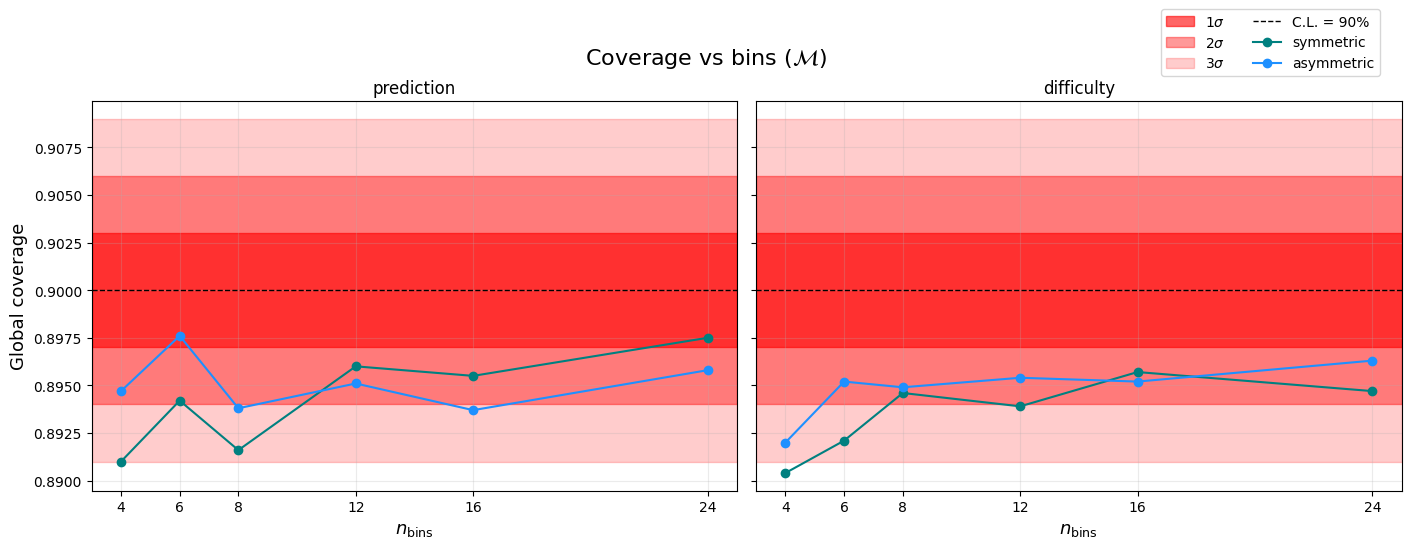

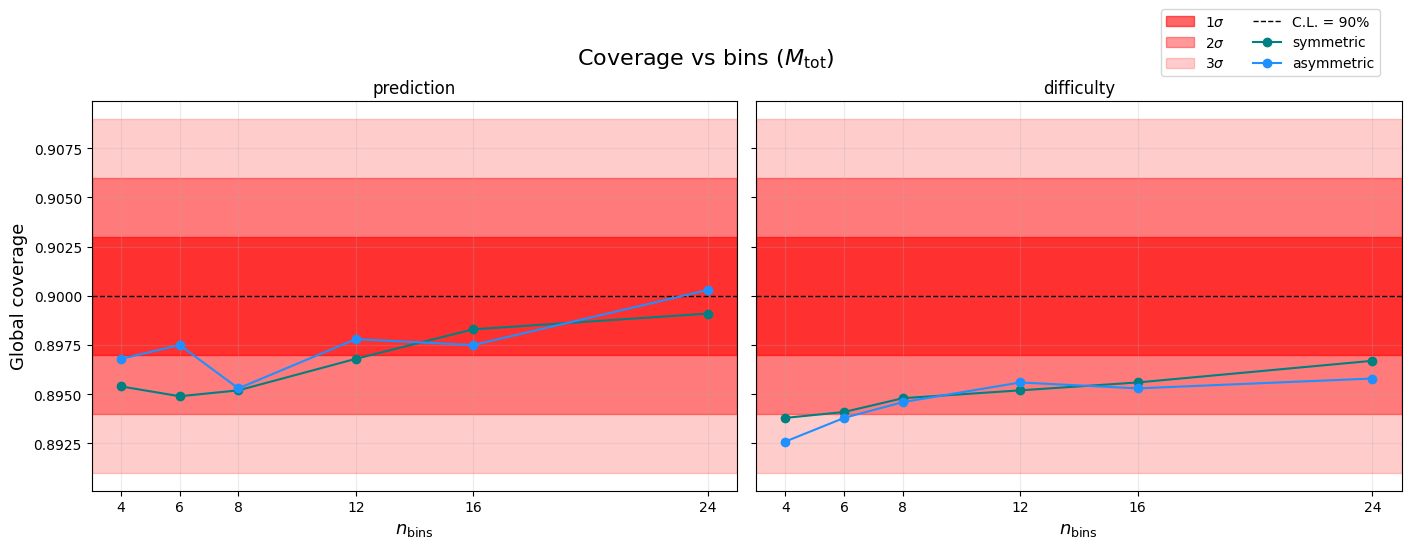

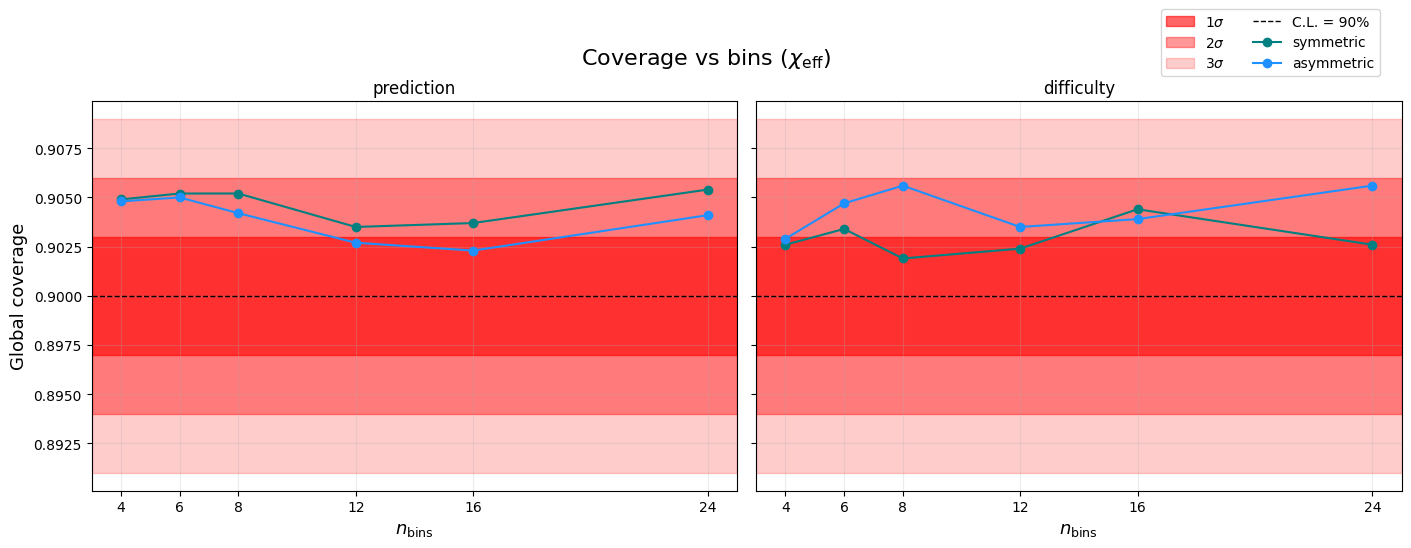

In [36]:
for label in label_names:
    plot_global_coverage_vs_bins(
        summary_df=summary_df,
        label=label,
        taxonomy_modes=taxonomy_modes,
        interval_modes=interval_modes,
        confidence_level=confidence_level,
        plot_labels=plot_labels,
        plot_colors=plot_colors,
    )

In [37]:
def plot_width_vs_bins(
    summary_df,
    label,
    taxonomy_modes,
    interval_modes,
    plot_labels,
    width_column="global_median_width_std",
    plot_colors=None,
):
    df_label = summary_df[summary_df["label"] == label]

    fig, axes = plt.subplots(
        1,
        len(taxonomy_modes),
        figsize=(14, 5),
        sharey=True,
        constrained_layout=True,
    )

    axes = np.atleast_1d(axes)

    for ax, taxonomy_mode in zip(axes, taxonomy_modes):
        df_tax = df_label[df_label["taxonomy_mode"] == taxonomy_mode]

        for interval_mode in interval_modes:
            df_mode = (
                df_tax[df_tax["interval_mode"] == interval_mode]
                .sort_values("n_bins")
            )

            color = None if plot_colors is None else plot_colors.get(interval_mode)

            ax.plot(
                df_mode["n_bins"],
                df_mode[width_column],
                marker="o",
                label=interval_mode,
                color=color,
            )

        ax.set_title(taxonomy_mode)
        ax.set_xlabel(r"$n_{\mathrm{bins}}$", fontsize=13)
        ax.set_xticks(sorted(df_tax["n_bins"].unique()))
        ax.grid(alpha=0.25)

    axes[0].set_ylabel(width_column, fontsize=13)
    fig.suptitle(f"Interval width vs bins ({plot_labels[label]})", fontsize=16)

    handles, labels_legend = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels_legend,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.08),
        ncol=2,
    )

    plt.show()

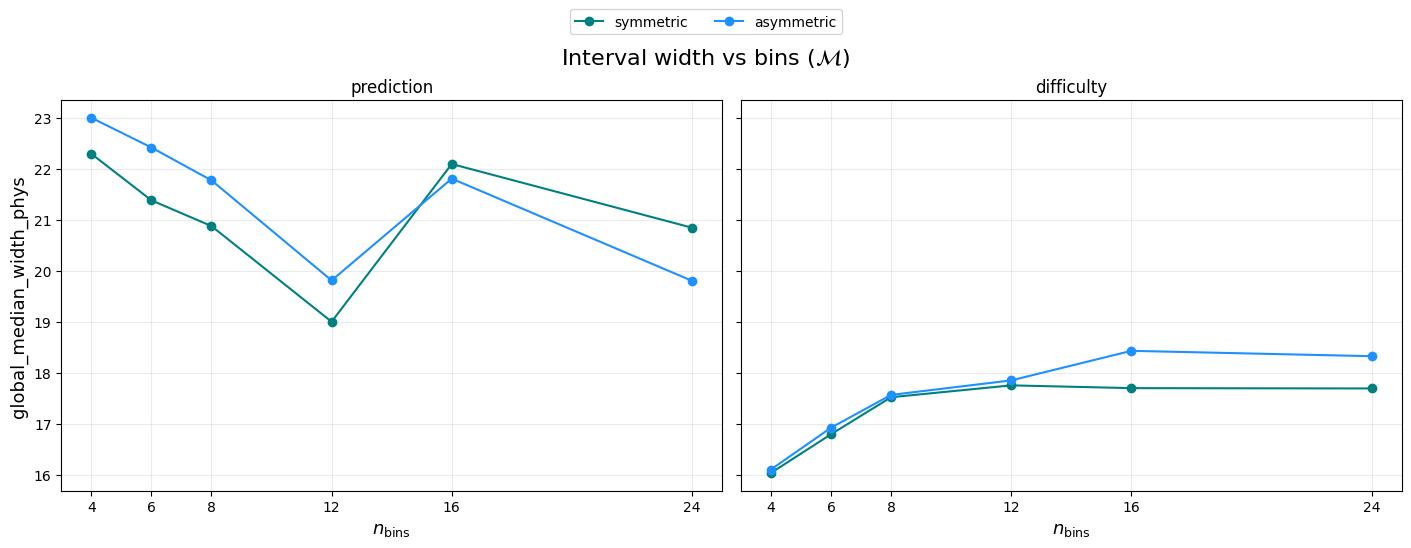

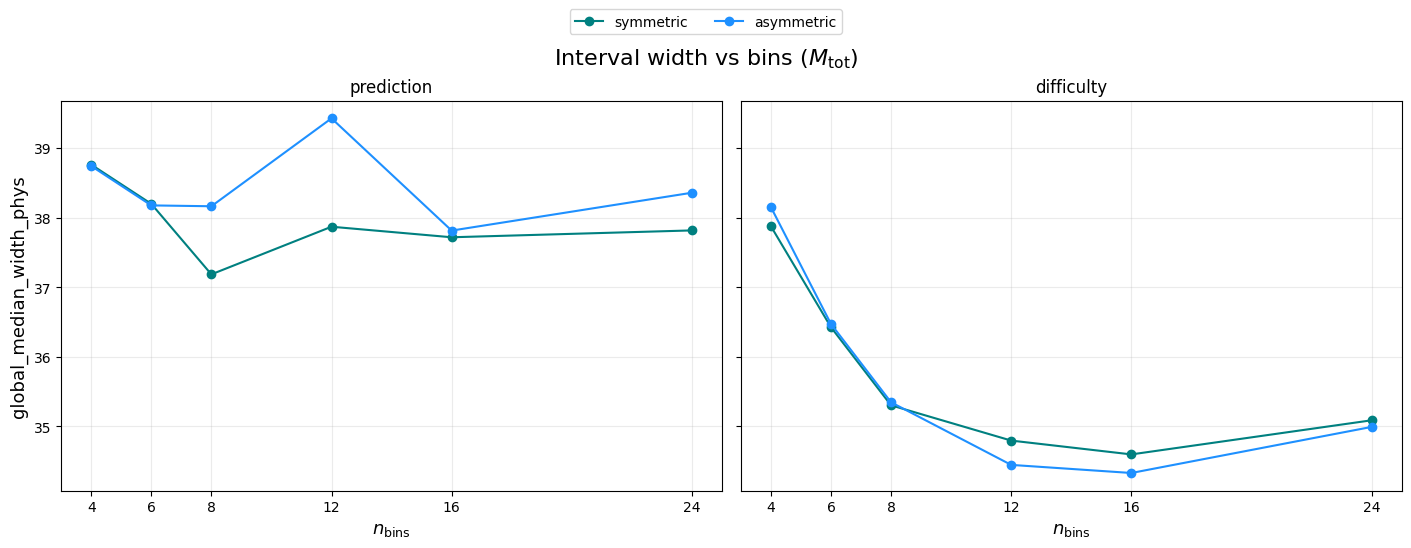

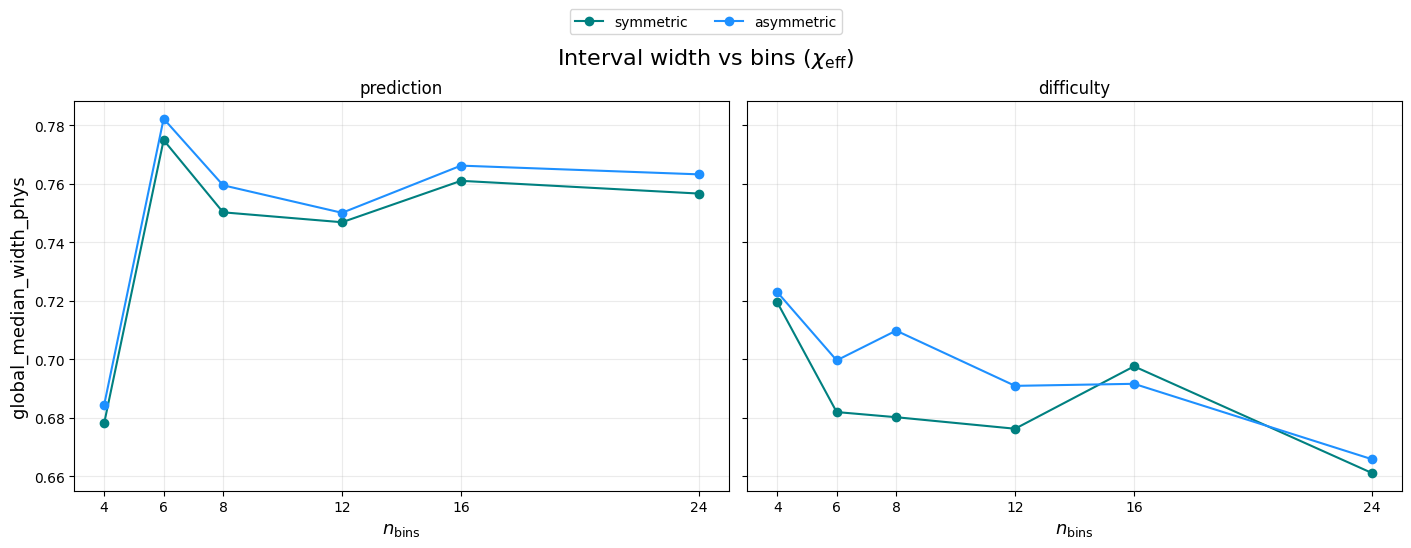

In [38]:
for label in label_names:
    plot_width_vs_bins(
        summary_df=summary_df,
        label=label,
        taxonomy_modes=taxonomy_modes,
        interval_modes=interval_modes,
        plot_labels=plot_labels,
        width_column="global_median_width_phys",
        plot_colors=plot_colors,
    )

In [22]:
def plot_coverage_width_tradeoff(
    summary_df,
    label,
    taxonomy_modes,
    interval_modes,
    confidence_level,
    plot_labels,
    width_column="global_median_width_std",
):
    df_label = summary_df[summary_df["label"] == label]

    scatter_color = {

    }

    plt.figure(figsize=(16, 10))

    for taxonomy_mode in taxonomy_modes:
        for interval_mode in interval_modes:
            df_mode = df_label[
                (df_label["taxonomy_mode"] == taxonomy_mode) &
                (df_label["interval_mode"] == interval_mode)
            ]

            plt.scatter(
                df_mode[width_column],
                df_mode["global_coverage"],
                s=350,
                label=f"{taxonomy_mode}-{interval_mode}",
            )

            for _, row in df_mode.iterrows():
                plt.text(
                    row[width_column],
                    row["global_coverage"],
                    str(row["n_bins"]),
                    fontsize=14,
                    ha="center",
                    va="center",
                    color="white",
                )

    plt.axhline(confidence_level, color="black", linestyle="--", linewidth=1)
    plt.xlabel(width_column)
    plt.ylabel("Global coverage")
    plt.title(f"Coverage-efficiency tradeoff ({plot_labels[label]})", fontsize=18)
    plt.grid(alpha=0.25)
    plt.legend(fontsize=14)
    plt.show()

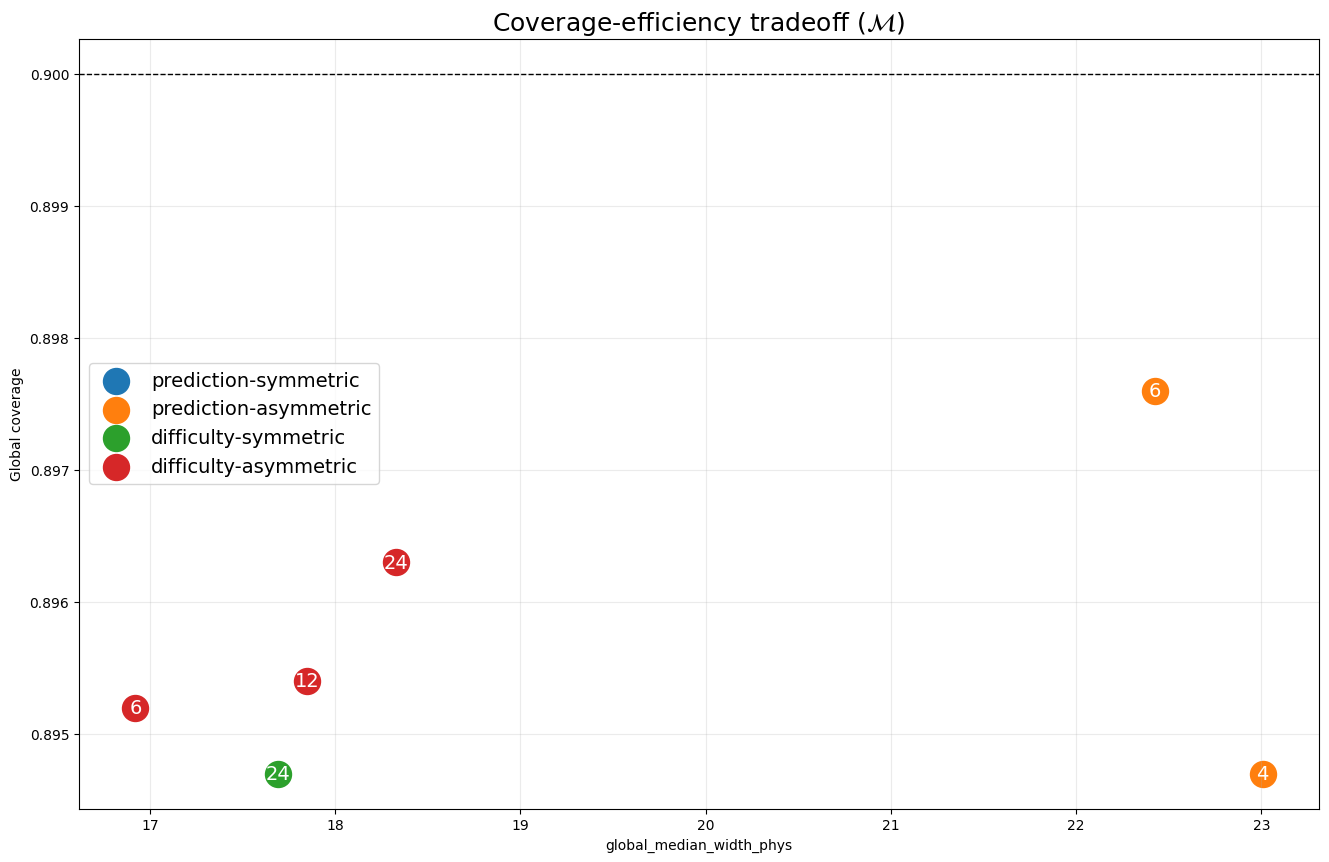

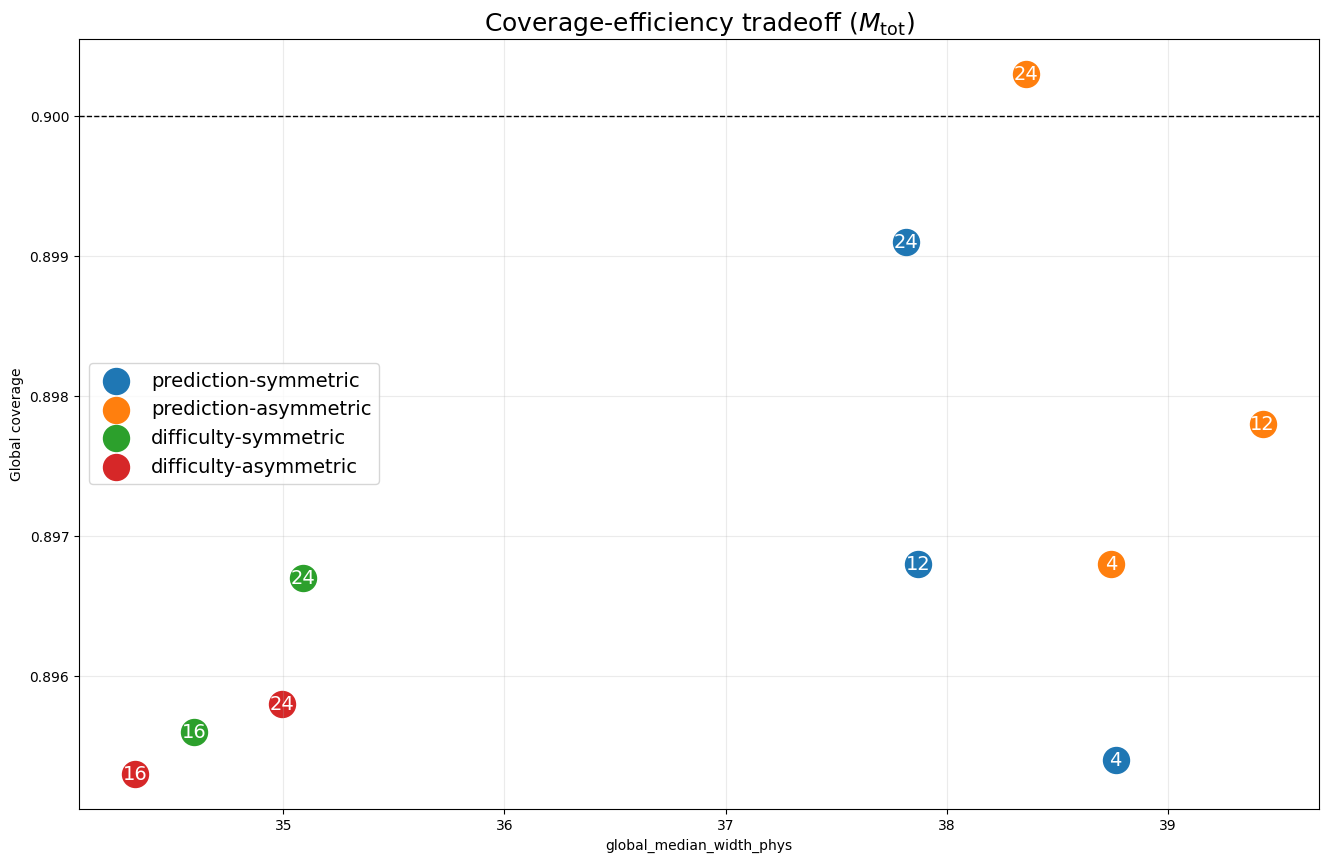

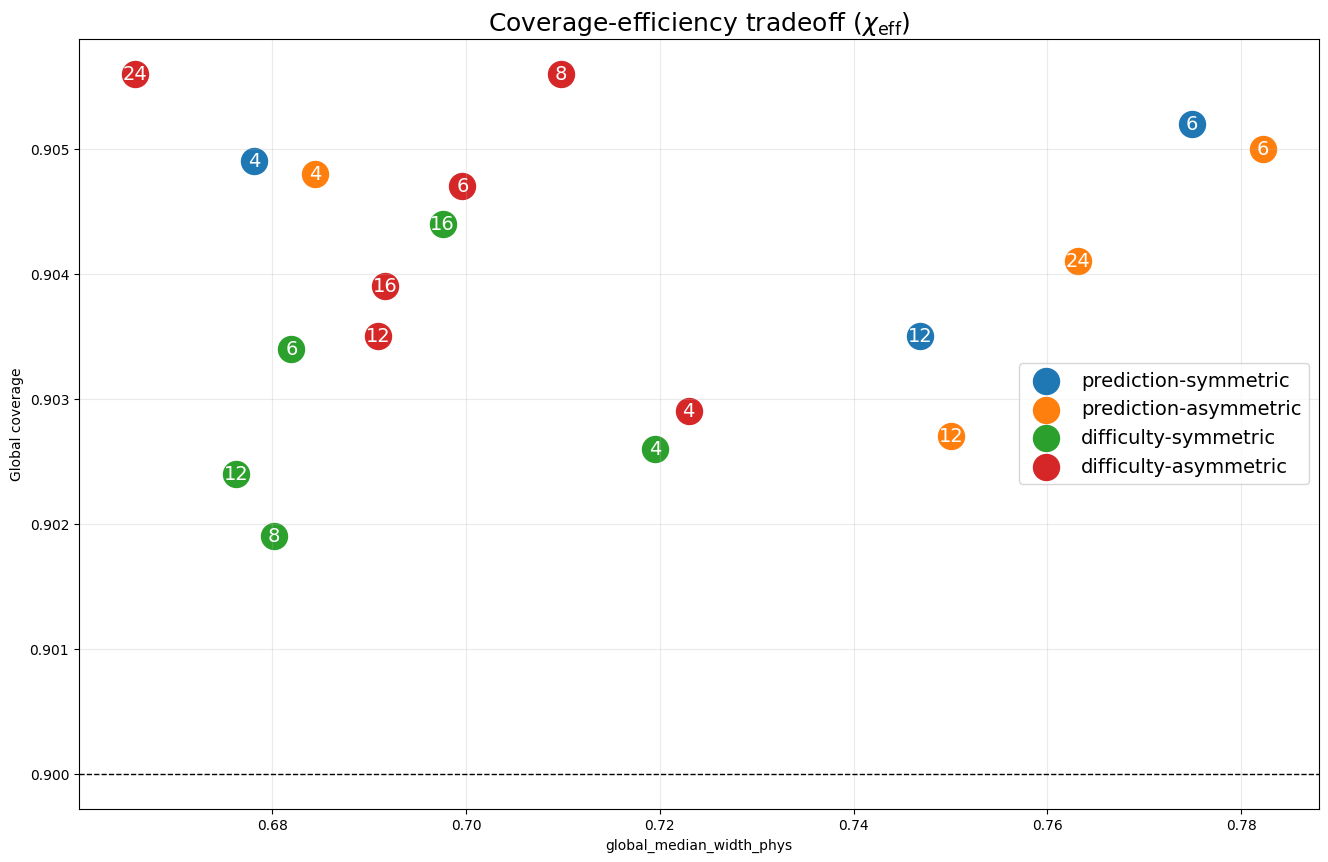

In [23]:
for label in label_names:
    plot_coverage_width_tradeoff(
        summary_df=candidate_df,
        label=label,
        taxonomy_modes=taxonomy_modes,
        interval_modes=interval_modes,
        confidence_level=confidence_level,
        plot_labels=plot_labels,
        width_column="global_median_width_phys",
    )

In [24]:
import numpy as np
import matplotlib.pyplot as plt


def plot_coverage_and_width_per_bin(
    all_results,
    key,
    label_idx,
    label_names,
    plot_labels,
    confidence_level,
    width_stat="mean",          # "mean" or "median"
    width_space="std",          # "std" or "phys"
    y_std=None,                 # required if width_space="phys"
    coverage_ylim=(0.85, 0.95),
    width_ylim=None,
    annotate_counts=True,
):
    result = all_results[key]
    metrics = result.metrics

    label = label_names[label_idx]
    title_label = plot_labels[label] if label in plot_labels else label

    coverage_per_bin = metrics["coverage_per_bin"][:, label_idx]
    counts_per_bin = metrics["counts_per_bin"][:, label_idx]
    bin_tol = metrics["bin_tolerance_normal"]

    n_bins = len(coverage_per_bin)
    x = np.arange(n_bins)

    # ------------------------------------------------------------------
    # Width per bin
    # ------------------------------------------------------------------
    width_key = f"{width_stat}_width_per_bin"

    if width_key in metrics:
        width_per_bin = metrics[width_key][:, label_idx].astype(float)
    else:
        # Fallback: compute from test intervals
        bin_indices_test = result.bin_indices_test
        widths = result.upper - result.lower  # (n_test, n_labels)

        width_per_bin = np.full(n_bins, np.nan)

        for b in range(n_bins):
            mask = bin_indices_test[:, label_idx] == b

            if np.sum(mask) == 0:
                continue

            if width_stat == "mean":
                width_per_bin[b] = np.mean(widths[mask, label_idx])
            elif width_stat == "median":
                width_per_bin[b] = np.median(widths[mask, label_idx])
            else:
                raise ValueError("width_stat must be 'mean' or 'median'.")

    if width_stat not in ["mean", "median"]:
        raise ValueError("width_stat must be 'mean' or 'median'.")

    if width_space == "phys":
        if y_std is None:
            raise ValueError("y_std must be provided when width_space='phys'.")

        width_per_bin = width_per_bin * y_std[label_idx]
        width_ylabel = f"{width_stat.capitalize()} interval width [{label}]"

    elif width_space == "std":
        width_ylabel = f"{width_stat.capitalize()} interval width [standardized]"

    else:
        raise ValueError("width_space must be 'std' or 'phys'.")

    # ------------------------------------------------------------------
    # Coverage bands
    # ------------------------------------------------------------------
    low_1 = bin_tol["1sigma_low"][:, label_idx]
    low_2 = bin_tol["2sigma_low"][:, label_idx]
    low_3 = bin_tol["3sigma_low"][:, label_idx]

    high_1 = bin_tol["1sigma_high"][:, label_idx]
    high_2 = bin_tol["2sigma_high"][:, label_idx]
    high_3 = bin_tol["3sigma_high"][:, label_idx]

    # ------------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------------
    fig, ax1 = plt.subplots(figsize=(9.5, 5.2))

    band_color = "tab:red"

    ax1.fill_between(
        x, low_3, high_3,
        color=band_color,
        alpha=0.10,
        label=r"Nominal 3$\sigma$",
        zorder=1,
    )

    ax1.fill_between(
        x, low_2, high_2,
        color=band_color,
        alpha=0.15,
        label=r"Nominal 2$\sigma$",
        zorder=2,
    )

    ax1.fill_between(
        x, low_1, high_1,
        color=band_color,
        alpha=0.20,
        label=r"Nominal 1$\sigma$",
        zorder=3,
    )

    ax1.plot(
        x,
        coverage_per_bin,
        marker="o",
        color="maroon",
        label="Empirical coverage",
        zorder=4,
    )

    ax1.axhline(
        confidence_level,
        linestyle="--",
        alpha=0.6,
        linewidth=1.0,
        color="black",
        label=rf"C.L. = {confidence_level}",
    )

    if annotate_counts:
        for i, n in enumerate(counts_per_bin):
            if np.isfinite(coverage_per_bin[i]):
                ax1.text(
                    i,
                    coverage_per_bin[i] + 0.005,
                    str(int(n)),
                    ha="center",
                    fontsize=9,
                    color="black",
                )

    ax1.set_xlabel("Bin index")
    ax1.set_ylabel("Coverage")
    ax1.set_ylim(*coverage_ylim)
    ax1.grid(alpha=0.25)

    # ------------------------------------------------------------------
    # Right axis: interval width
    # ------------------------------------------------------------------
    ax2 = ax1.twinx()

    ax2.plot(
        x,
        width_per_bin,
        marker="s",
        linestyle="-",
        color="tab:blue",
        label=f"{width_stat} interval width",
        zorder=5,
    )

    ax2.set_ylabel(width_ylabel)

    if width_ylim is not None:
        ax2.set_ylim(*width_ylim)

    ax1.set_title(
        f"Coverage and interval width per bin | {title_label} | {key}"
    )

    # Combine legends
    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()

    ax1.legend(
        handles1 + handles2,
        labels1 + labels2,
        ncols=2,
        loc="lower right",
    )

    plt.tight_layout()
    plt.show()

    return width_per_bin

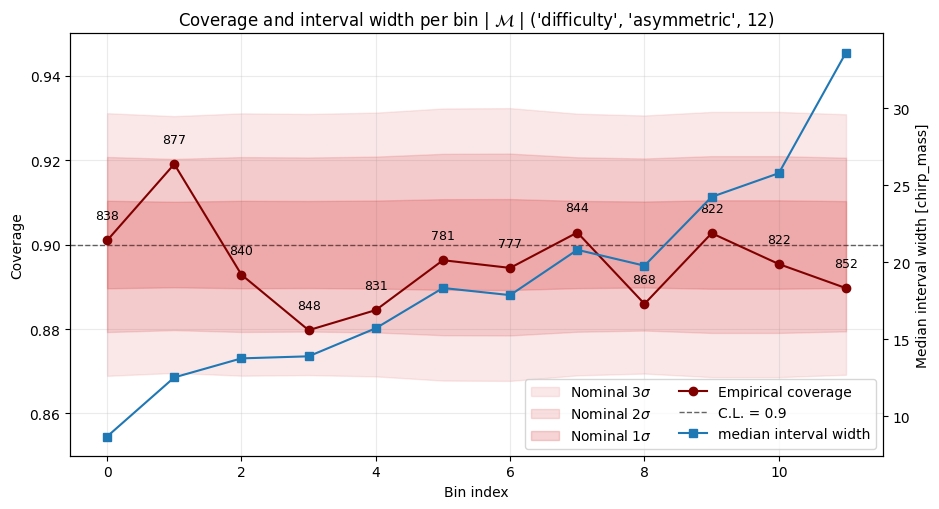

In [25]:
key = ("difficulty", "asymmetric", 12)

width_per_bin_phys = plot_coverage_and_width_per_bin(
    all_results=all_results,
    key=key,
    label_idx=0,
    label_names=label_names,
    plot_labels=plot_labels,
    confidence_level=0.90,
    width_stat="median",
    width_space="phys",
    y_std=y_std,
)
    

## Final candidate configurations under local-validity criteria

In [26]:

# ============================================================
# Final best config per label under the local-validity ranking
# ============================================================

best_by_label = (
    ranking_df
    .groupby("label", group_keys=False)
    .head(1)
    .reset_index(drop=True)
)

final_cols = [
    "label",
    "taxonomy_mode",
    "interval_mode",
    "n_bins",
    "global_coverage",
    global_col,
    "min_bin_coverage",
    "max_undercoverage_gap",
    n_under_col,
    under_frac_col,
    beyond_col,
    "global_median_width_std",
    "global_median_width_phys",
    "normalized_median_width_range",
    "rel_width_excess",
    "global_lower_miss_rate",
    "global_upper_miss_rate",
    "global_tail_miss_imbalance",
    "min_count_per_bin",
]

best_by_label[final_cols]


,label,taxonomy_mode,interval_mode,n_bins,global_coverage,global_within_2sigma,min_bin_coverage,max_undercoverage_gap,n_under_bins_2sigma,under_bin_fraction_2sigma,max_undercoverage_beyond_2sigma,global_median_width_std,global_median_width_phys,normalized_median_width_range,rel_width_excess,global_lower_miss_rate,global_upper_miss_rate,global_tail_miss_imbalance,min_count_per_bin
0,chi_eff,difficulty,asymmetric,24,0.9056,True,0.858156,0.041844,1,0.041667,0.012671,1.515488,0.665867,0.335781,0.000000,0.0494,0.0450,0.0044,349
1,chirp_mass,difficulty,asymmetric,6,0.8952,True,0.887441,0.012559,0,0.000000,0.000000,1.023889,16.922081,0.232371,0.000000,0.0526,0.0522,0.0004,1612
2,total_mass,difficulty,asymmetric,24,0.8958,True,0.871046,0.028954,0,0.000000,0.000000,1.007390,34.993627,0.209218,0.019284,0.0552,0.0490,0.0062,370


Best configuration for label: chi_eff
key = ('difficulty', 'asymmetric', 24)
Configuration: ('difficulty', 'asymmetric', 24)
Label: chi_eff

Counts per bin:
[423 419 383 438 434 419 410 374 398 420 415 389 398 435 349 437 454 376
 449 412 429 460 452 427]

Coverage per bin:
[0.858 0.909 0.909 0.904 0.924 0.919 0.888 0.909 0.925 0.893 0.918 0.884
 0.892 0.901 0.897 0.918 0.941 0.88  0.913 0.92  0.916 0.915 0.903 0.89 ]

Covered count per bin:
[363 381 348 396 401 385 364 340 368 375 381 344 355 392 313 401 427 331
 410 379 393 421 408 380]

Bin undercoverage p-values:
[0.0039 0.7599 0.7369 0.636  0.9636 0.9177 0.2264 0.7452 0.9618 0.3356
 0.9078 0.1712 0.3196 0.5552 0.4481 0.9074 0.9992 0.1193 0.8432 0.9272
 0.8852 0.8799 0.5975 0.2655]

Lower miss rate per bin:
[0.043 0.045 0.044 0.057 0.037 0.057 0.071 0.043 0.03  0.069 0.046 0.044
 0.065 0.039 0.037 0.041 0.024 0.085 0.051 0.041 0.058 0.057 0.053 0.049]

Upper miss rate per bin:
[0.099 0.045 0.047 0.039 0.039 0.024 0.041 0.048 0.045 

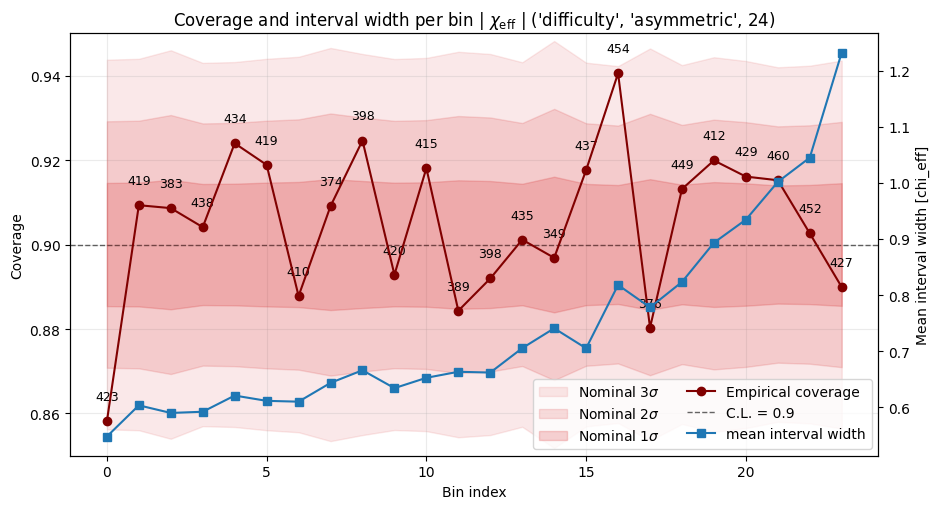

Best configuration for label: chirp_mass
key = ('difficulty', 'asymmetric', 6)
Configuration: ('difficulty', 'asymmetric', 6)
Label: chirp_mass

Counts per bin:
[1715 1688 1612 1621 1690 1674]

Coverage per bin:
[0.905 0.887 0.888 0.901 0.902 0.888]

Covered count per bin:
[1552 1498 1431 1460 1524 1487]

Bin undercoverage p-values:
[0.764  0.0484 0.0564 0.5484 0.6079 0.0616]

Lower miss rate per bin:
[0.039 0.057 0.053 0.054 0.053 0.06 ]

Upper miss rate per bin:
[0.056 0.055 0.06  0.045 0.046 0.052]

Interval offsets per bin:
[[-0.3329  0.317 ]
 [-0.4117  0.4244]
 [-0.5367  0.4872]
 [-0.6176  0.558 ]
 [-0.7251  0.6246]
 [-0.9574  0.8519]]

Calibrator bin counts:
[1667 1666 1667 1666 1667 1667]

Quantile indices:
[[  83 1584]
 [  83 1583]
 [  83 1584]
 [  83 1583]
 [  83 1584]
 [  83 1584]]


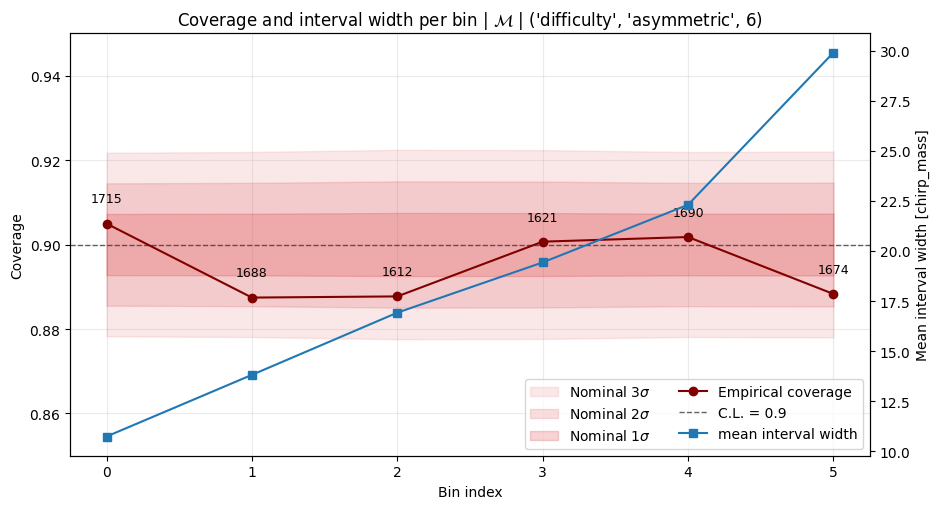

Best configuration for label: total_mass
key = ('difficulty', 'asymmetric', 24)
Configuration: ('difficulty', 'asymmetric', 24)
Label: total_mass

Counts per bin:
[370 419 406 441 412 425 426 457 410 414 380 411 419 392 392 410 450 450
 429 377 396 456 416 442]

Coverage per bin:
[0.922 0.893 0.894 0.912 0.917 0.896 0.885 0.893 0.888 0.872 0.879 0.871
 0.897 0.893 0.895 0.885 0.911 0.898 0.904 0.91  0.917 0.895 0.894 0.88 ]

Covered count per bin:
[341 374 363 402 378 381 377 408 364 361 334 358 376 350 351 363 410 404
 388 343 363 408 372 389]

Bin undercoverage p-values:
[0.9338 0.3296 0.3692 0.8119 0.8997 0.4275 0.1697 0.3252 0.2264 0.038
 0.1021 0.0339 0.4526 0.3423 0.4051 0.1815 0.8049 0.4604 0.6435 0.7611
 0.885  0.3762 0.3707 0.0964]

Lower miss rate per bin:
[0.059 0.064 0.062 0.039 0.039 0.042 0.063 0.066 0.076 0.068 0.061 0.058
 0.05  0.046 0.061 0.078 0.056 0.029 0.056 0.037 0.045 0.053 0.06  0.059]

Upper miss rate per bin:
[0.019 0.043 0.044 0.05  0.044 0.061 0.052 0.042 0

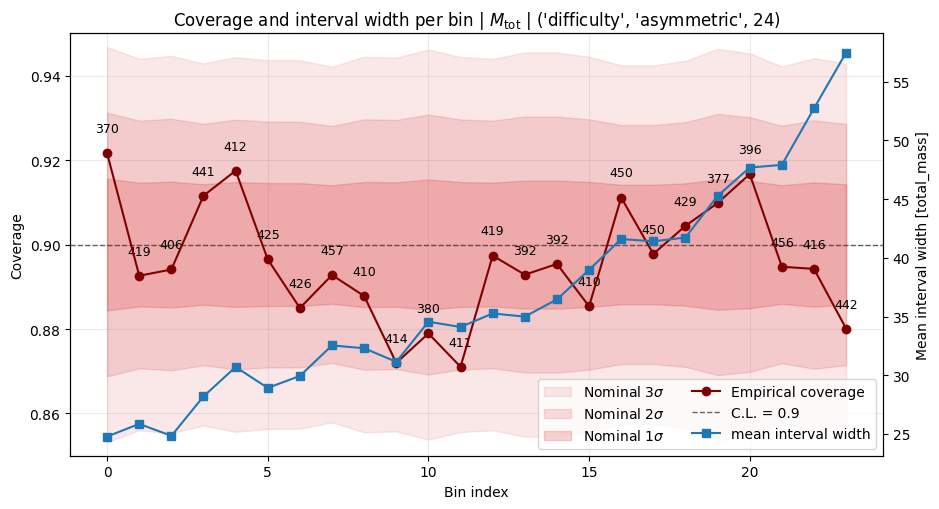

In [27]:
for row in best_by_label.itertuples():
    key = (row.taxonomy_mode, row.interval_mode, row.n_bins)
    label_idx = int(row.label_index)
    label = label_names[label_idx]

    print("=" * 80)
    print(f"Best configuration for label: {label}")
    print(f"key = {key}")
    print("=" * 80)

    inspect_configuration(
        all_results=all_results,
        key=key,
        label_idx=label_idx,
        label_names=label_names,
    )

    width_per_bin_phys = plot_coverage_and_width_per_bin(
        all_results=all_results,
        key=key,
        label_idx=label_idx,
        label_names=label_names,
        plot_labels=plot_labels,
        confidence_level=0.90,
        width_stat="mean",
        width_space="phys",
        y_std=y_std,
    )

In [28]:
key = (row.taxonomy_mode, row.interval_mode, row.n_bins)
label_idx = int(row.label_index)

result = all_results[key]
metrics = result.metrics

print("key:", key)
print("label:", label_names[label_idx])

print("coverage_per_bin:")
print(metrics["coverage_per_bin"][:, label_idx])

print("counts_per_bin:")
print(metrics["counts_per_bin"][:, label_idx])

print("mean_width_per_bin:")
print(metrics["mean_width_per_bin"][:, label_idx])

print("median_width_per_bin:")
print(metrics["median_width_per_bin"][:, label_idx])

key: ('difficulty', 'asymmetric', 24)
label: total_mass
coverage_per_bin:
[0.92162162 0.89260143 0.89408867 0.91156463 0.91747573 0.89647059
 0.88497653 0.89277899 0.88780488 0.87198068 0.87894737 0.87104623
 0.8973747  0.89285714 0.89540816 0.88536585 0.91111111 0.89777778
 0.9044289  0.90981432 0.91666667 0.89473684 0.89423077 0.8800905 ]
counts_per_bin:
[370 419 406 441 412 425 426 457 410 414 380 411 419 392 392 410 450 450
 429 377 396 456 416 442]
mean_width_per_bin:
[0.71326926 0.74420027 0.71492767 0.81161347 0.88378024 0.83254491
 0.86183444 0.93680477 0.92977138 0.89647487 0.99482583 0.98188078
 1.01507564 1.00738961 1.04968619 1.12214078 1.19770557 1.19196418
 1.20139968 1.30348349 1.37299013 1.37957388 1.51812196 1.65510247]
median_width_per_bin:
[0.71326926 0.74420027 0.71492767 0.81161347 0.88378024 0.83254491
 0.86183444 0.93680477 0.92977138 0.89647487 0.99482583 0.98188078
 1.01507564 1.00738961 1.04968619 1.12214078 1.19770557 1.19196418
 1.20139968 1.30348349 1.37299

In [29]:
mean_w = metrics["mean_width_per_bin"][:, label_idx]
median_w = metrics["median_width_per_bin"][:, label_idx]

print("mean == median per bin?")
print(np.allclose(mean_w, median_w, equal_nan=True))

print("width changes across bins?")
print(np.nanmin(mean_w), np.nanmax(mean_w))
print("unique rounded widths:")
print(np.unique(np.round(mean_w, 6)))

mean == median per bin?
True
width changes across bins?
0.7132692635059357 1.6551024727523327
unique rounded widths:
[0.713269 0.714928 0.7442   0.811613 0.832545 0.861834 0.88378  0.896475
 0.929771 0.936805 0.981881 0.994826 1.00739  1.015076 1.049686 1.122141
 1.191964 1.197706 1.2014   1.303483 1.37299  1.379574 1.518122 1.655102]
